# Ensemble XGBoost для предсказания цен

## Импорты

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
def calculateMetrics(yTrue: np.ndarray, yPred: np.ndarray, modelName: str = "Model") -> None:
    mae = mean_absolute_error(yTrue, yPred)
    rmse = np.sqrt(mean_squared_error(yTrue, yPred))
    mape = mean_absolute_percentage_error(yTrue, yPred) * 100
    print(f"{modelName.upper()} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")

## Загрузка данных

In [15]:
trainDataFrame = pd.read_csv('data/train.csv')
testDataFrame = pd.read_csv('data/test_x.csv')

print(f"Train shape: {trainDataFrame.shape}")
print(f"Test shape: {testDataFrame.shape}")

Train shape: (29905, 83)
Test shape: (7477, 83)


### Первый взгляд

In [16]:
display(trainDataFrame.head(3))
display(trainDataFrame.describe())

,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.0,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.0,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.0,0.945618,7.0,18311.834458,284,49786.0,97865,70661


,district_cat,corpus_cat,developer_cat,floor,square,location_logs_count_mean,location_depth,location_logs_count_std,location_flash_mean_mean,location_hds_ratio_mean_mean,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
count,29905.000000,29905.000000,29905.000000,29905.000000,29905.000000,29572.000000,29572.0,29572.000000,29572.000000,29572.000000,...,29572.000000,29572.000000,29572.000000,29572.000000,29572.000000,29905.000000,29905.000000,29905.000000,29905.000000,29905.000000
mean,51.564621,1263.651129,73.761779,9.713125,57.470088,22.378914,13.0,25.017475,0.211902,1.295069,...,-7.875600,-307.290970,-689.842065,0.888430,8.830718,24606.729857,254.002675,19510.513158,77870.095469,43767.466845
std,23.717749,700.273954,29.491876,6.096880,25.523398,2.474799,0.0,12.711157,0.029187,0.073910,...,93.165568,461.766719,462.132973,0.099720,5.584762,10045.795459,109.070862,21911.397338,32650.894231,27287.683879
min,1.000000,3.000000,2.000000,-9.000000,18.660000,13.178136,13.0,6.480796,0.090068,0.835207,...,-999.000000,-999.000000,-999.000000,0.231314,0.000000,15859.265133,2.000000,0.000000,2581.000000,103.000000
25%,41.000000,737.000000,58.000000,5.000000,38.850000,21.521521,13.0,20.392994,0.194393,1.290643,...,0.832622,-999.000000,-999.000000,0.828147,4.000000,18019.041560,181.000000,0.000000,27353.000000,12638.000000
50%,48.000000,1188.000000,77.000000,9.000000,51.510000,22.574287,13.0,22.389158,0.212908,1.316139,...,0.881220,0.837294,-999.000000,0.895532,8.000000,22257.192093,270.000000,8977.000000,97865.000000,27728.000000
75%,71.000000,1881.000000,91.000000,13.000000,69.580000,23.743690,13.0,24.488793,0.230561,1.333026,...,0.921279,1.019665,0.746081,0.952028,12.000000,27639.644836,341.000000,49786.000000,97865.000000,70661.000000
max,100.000000,2428.000000,134.000000,211.000000,427.230000,33.396234,13.0,106.070634,0.307842,1.384783,...,1.165174,1.611869,1.559104,1.263878,25.000000,142207.315609,457.000000,49786.000000,97865.000000,70661.000000


In [17]:
targetColumn = 'price_target'
yTarget = trainDataFrame[targetColumn].values
trainDataFrame = trainDataFrame.drop(columns=[targetColumn])

testIds = testDataFrame['id'].values if 'id' in testDataFrame.columns else np.arange(len(testDataFrame))
testDataFrame = testDataFrame.drop(columns=['id'])

### Пропуски и -999

In [18]:
print("Количество -999 в train (топ-10):")
missingCountTrain = (trainDataFrame == -999).sum().sort_values(ascending=False)
print(missingCountTrain.head(10))

Количество -999 в train (топ-10):
location_town_w_mean_distance               21210
location_university_w_mean_distance         20429
location_commercial_w_mean_distance         19517
location_amenity_leisure_w_mean_distance    10497
location_water_w_mean_distance               9116
location_hotel_w_mean_distance               8234
location_industrial_w_mean_distance          5437
location_railway_station_w_mean_distance     4866
location_social_w_mean_distance              4837
location_shop_alco_w_mean_distance           3672
dtype: int64


### Типы данных

In [19]:
print(trainDataFrame.dtypes)
trainDataFrame.dtypes.to_csv('dtypes.csv')

numericColumns = trainDataFrame.select_dtypes(include=[np.number]).columns
categoricalColumns = trainDataFrame.select_dtypes(exclude=[np.number]).columns

print(f"\nЧисловых признаков: {len(numericColumns)}")
print(f"Категориальных признаков: {len(categoricalColumns)}")

if len(categoricalColumns) > 0:
    print(f"\nКатегориальные признаки:")
    for colName in categoricalColumns:
        uniqueCount = trainDataFrame[colName].nunique()
        print(f"  {colName}: {uniqueCount} уникальных значений")

region_name_cat              str
district_cat               int64
corpus_cat                 int64
developer_cat              int64
agreement_date               str
                          ...   
location_pop_shop_cnt    float64
hc_name_cat                int64
interior_cat             float64
class_cat                  int64
stage_cat                  int64
Length: 82, dtype: object

Числовых признаков: 79
Категориальных признаков: 3

Категориальные признаки:
  region_name_cat: 3 уникальных значений
  agreement_date: 529 уникальных значений
  rooms_4: 5 уникальных значений


### Предобработка

In [20]:
for columnName in trainDataFrame.columns:
    if trainDataFrame[columnName].dtype == 'str':
        labelEncoder = LabelEncoder()
        combinedData = pd.concat([trainDataFrame[columnName].astype(str), testDataFrame[columnName].astype(str)])
        labelEncoder.fit(combinedData)
        trainDataFrame[columnName] = labelEncoder.transform(trainDataFrame[columnName].astype(str))
        testDataFrame[columnName] = labelEncoder.transform(testDataFrame[columnName].astype(str))

trainDataFrame = trainDataFrame.replace(-999, np.nan)
testDataFrame = testDataFrame.replace(-999, np.nan)

for columnName in trainDataFrame.columns:
    combinedDF = pd.concat([trainDataFrame, testDataFrame], axis=0, ignore_index=True)
    medianValue = combinedDF[columnName].median()
    trainDataFrame[columnName] = trainDataFrame[columnName].fillna(medianValue)
    testDataFrame[columnName] = testDataFrame[columnName].fillna(medianValue)

trainFeatures = trainDataFrame.values.astype(np.float64)
testFeatures = testDataFrame.values.astype(np.float64)

print(f"Итоговое количество признаков: {trainFeatures.shape[1]}")

Итоговое количество признаков: 82


In [21]:
trainDataFrame = trainDataFrame.replace(-999, np.nan)
testDataFrame = testDataFrame.replace(-999, np.nan)

for columnName in trainDataFrame.columns:
    combinedDF = pd.concat([trainDataFrame, testDataFrame], axis=0, ignore_index=True)
    medianValue = combinedDF[columnName].median()
    trainDataFrame[columnName] = trainDataFrame[columnName].fillna(medianValue)
    testDataFrame[columnName] = testDataFrame[columnName].fillna(medianValue)

trainFeatures = trainDataFrame.values.astype(np.float64)
testFeatures = testDataFrame.values.astype(np.float64)

print(f"Итоговое количество признаков: {trainFeatures.shape[1]}")

Итоговое количество признаков: 82


## Обучение ансамбля моделей

In [22]:
def createXgboostRegressor(random_state=42) -> xgb.XGBRegressor:
    return xgb.XGBRegressor(
        n_estimators=6000,
        max_depth=16,
        learning_rate=0.009,
        subsample=0.72,
        colsample_bytree=0.68,
        min_child_weight=1,
        reg_alpha=0.04,
        reg_lambda=0.5,
        random_state=random_state,
        n_jobs=-1,
        verbosity=0
    )

In [23]:
yLogTarget = np.log(yTarget)

randomSeedsList = [42, 123, 456, 789, 2024]

print(f"\nОбучение {len(randomSeedsList)} моделей XGBoost с разными сидами...\n")

trainPredictionsList = []
testPredictionsList = []

for seedIndex, randomSeed in enumerate(randomSeedsList):
    print(f"Модель {seedIndex + 1}/{len(randomSeedsList)} (seed={randomSeed})")

    currentModel = createXgboostRegressor(random_state=randomSeed)
    currentModel.fit(trainFeatures, yLogTarget, verbose=False)

    currentTrainPredLog = currentModel.predict(trainFeatures)
    currentTrainPred = np.exp(currentTrainPredLog)
    trainPredictionsList.append(currentTrainPred)

    currentTestPredLog = currentModel.predict(testFeatures)
    currentTestPred = np.exp(currentTestPredLog)
    testPredictionsList.append(currentTestPred)

    calculateMetrics(yTarget, currentTrainPred, f"Model seed={randomSeed}")

trainPredictionsArray = np.array(trainPredictionsList)
testPredictionsArray = np.array(testPredictionsList)


Обучение 5 моделей XGBoost с разными сидами...

Модель 1/5 (seed=42)
MODEL SEED=42 → MAE: 73.72 | RMSE: 129.60 | MAPE: 0.29%
Модель 2/5 (seed=123)
MODEL SEED=123 → MAE: 73.10 | RMSE: 128.40 | MAPE: 0.29%
Модель 3/5 (seed=456)
MODEL SEED=456 → MAE: 73.47 | RMSE: 128.97 | MAPE: 0.29%
Модель 4/5 (seed=789)
MODEL SEED=789 → MAE: 73.66 | RMSE: 129.23 | MAPE: 0.29%
Модель 5/5 (seed=2024)
MODEL SEED=2024 → MAE: 73.38 | RMSE: 128.81 | MAPE: 0.29%


## Оптимизация весов ансамбля

In [24]:
def ensembleLossFunction(weights: np.ndarray) -> float:
    weights = weights / weights.sum()
    ensemblePrediction = np.sum(trainPredictionsArray * weights[:, None], axis=0)
    return mean_absolute_error(yTarget, ensemblePrediction)

initialWeights = np.ones(len(randomSeedsList)) / len(randomSeedsList)
weightsConstraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
weightsBounds = [(0.0, 1.0) for _ in range(len(randomSeedsList))]

optimizationResult = minimize(
    ensembleLossFunction,
    initialWeights,
    method='SLSQP',
    bounds=weightsBounds,
    constraints=weightsConstraints
)

optimalWeights = optimizationResult.x
optimalWeights = optimalWeights / optimalWeights.sum()

print("\nОптимальные веса моделей:")
for seedIndex, (randomSeed, weight) in enumerate(zip(randomSeedsList, optimalWeights)):
    print(f"  Model seed={randomSeed}: {weight:.4f}")


Оптимальные веса моделей:
  Model seed=42: 0.0000
  Model seed=123: 0.5449
  Model seed=456: 0.1699
  Model seed=789: 0.0118
  Model seed=2024: 0.2735


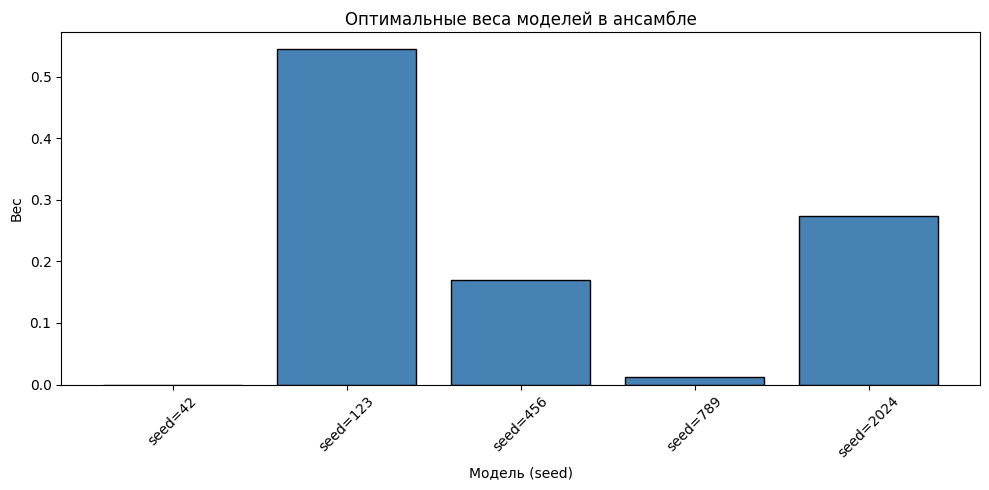

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(randomSeedsList)), optimalWeights, color='steelblue', edgecolor='black')
plt.xlabel('Модель (seed)')
plt.ylabel('Вес')
plt.title('Оптимальные веса моделей в ансамбле')
plt.xticks(range(len(randomSeedsList)), [f'seed={s}' for s in randomSeedsList], rotation=45)
plt.tight_layout()
plt.show()

## Финальные метрики и submission

In [26]:
ensembleTrainPrediction = np.sum(trainPredictionsArray * optimalWeights[:, None], axis=0)
ensembleTestPrediction = np.sum(testPredictionsArray * optimalWeights[:, None], axis=0)

calculateMetrics(yTarget, ensembleTrainPrediction, "Weighted Ensemble")

WEIGHTED ENSEMBLE → MAE: 72.94 | RMSE: 128.25 | MAPE: 0.28%


In [27]:
submission = pd.DataFrame({
    'id': testIds,
    'price_target': ensembleTestPrediction
})

submission.to_csv('submission_ensemble.csv', index=False)
print("\nСохранен файл submission_ensemble.csv")

print("\nПервые 10 предсказаний:")
print(submission.head(10))


Сохранен файл submission_ensemble.csv

Первые 10 предсказаний:
   id  price_target
0   0  22280.689840
1   1  23343.438042
2   2  27357.200896
3   3  18799.933769
4   4  19741.455159
5   5  17864.230953
6   6  21507.059380
7   7  62951.388242
8   8  24508.482195
9   9  16580.376178
